# pDC half-violin expression plots

Remote source reviewed from `20250709p38-修/pDC半小提琴图.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
library(Seurat)      # 用于处理单细胞数据
library(tidyverse)   # 用于数据整理和 ggplot2 绘图 (包含 dplyr, ggplot2 等)
library(gghalves)    # 用于绘制半小提琴图 (geom_half_violin)
library(reshape2)    # 用于数据格式转换 (melt 函数) - tidyr::pivot_longer 是更新的选择，但 melt 也能工作
seu <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() mas

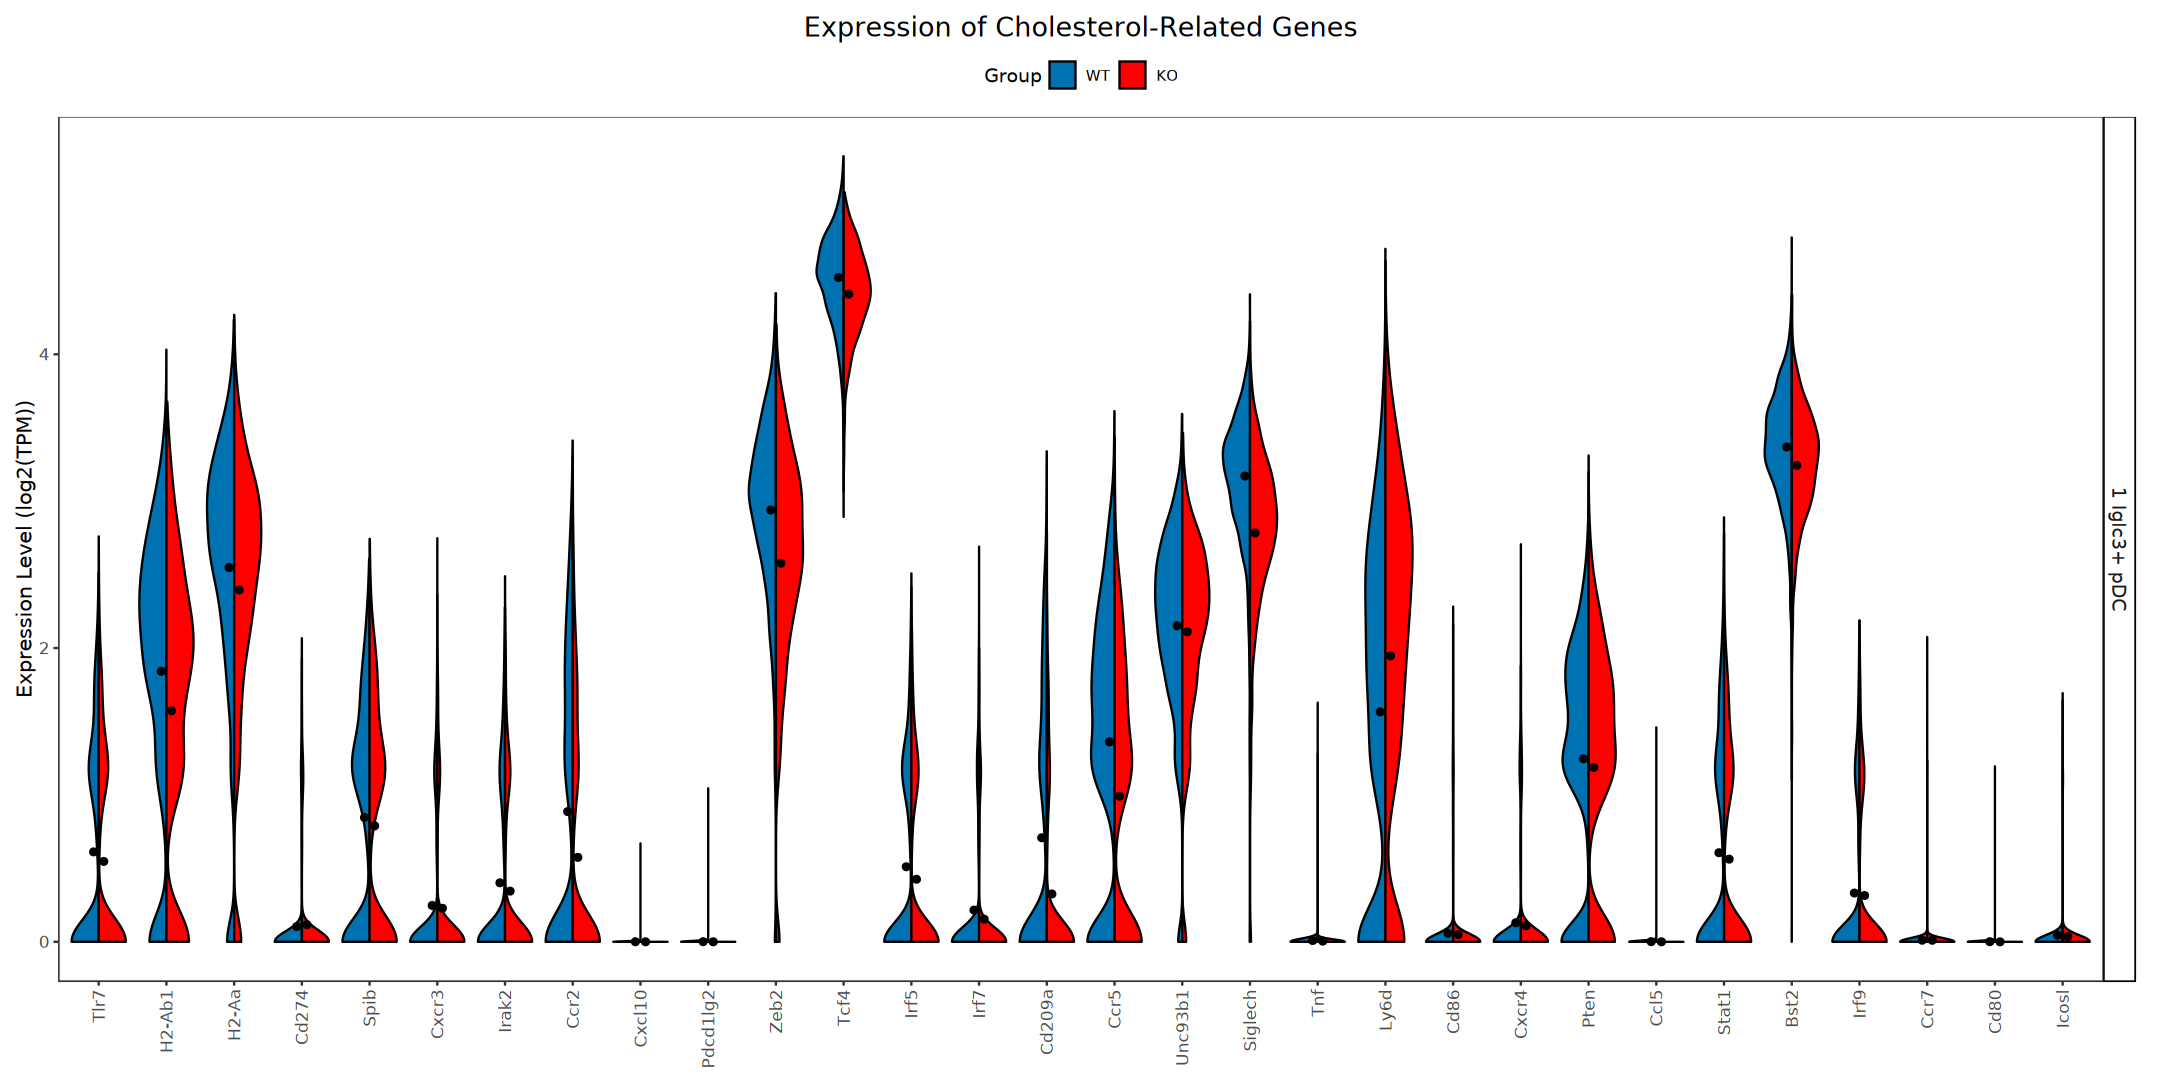

In [4]:
# 定义感兴趣的巨噬细胞亚群名称 (确保与 Seurat 对象中的元数据 'celltype' 列匹配)
mac_cell_types <- c("1 Iglc3+ pDC")

# 定义要可视化的胆固醇相关基因列表
cholesterol_genes <- c("Tlr7", "H2-Ab1","H2-Aa","Cd274", "Spib",
    "Cxcr3",
    "Irak2",
    "Ccr2",
    "Cxcl10",
    "Pdcd1lg2",
    "Zeb2",
    "Tcf4",
    "Irf5",
    "Irf7",
    "Cd209a",
    "Ccr5",
    "Unc93b1",
    "Siglech",
    "Tnf",
    "Ly6d",
    "Cd86",
    "Cxcr4",
    "Pten",
    "Ccl5",
    "Stat1",
    "Bst2",
    "Irf9",
    "Ccr7",
    "Cd80",
    "Icosl")

# 定义分组颜色 (确保 'WT' 和 'KO' 与 Seurat 对象中的分组标识符匹配，通常是 'orig.ident')
group_colors <- c("WT" = "#0072B2", "KO" = "#FF0000")

# 从 Seurat 对象中筛选出指定类型的巨噬细胞
mac_cells <- subset(seu, subset = celltype %in% mac_cell_types)

# 提取指定基因的表达数据 (通常使用 log 标准化后的数据，位于 "data" slot)
# 确保 assay 名称正确 (例如 "RNA" 或 "SCT")
expr_matrix <- GetAssayData(mac_cells, slot = "data", assay = "RNA")

# 检查并仅保留 Seurat 对象中实际存在的基因
genes_present <- intersect(cholesterol_genes, rownames(expr_matrix))
if (length(genes_present) < length(cholesterol_genes)) {
  missing_genes <- setdiff(cholesterol_genes, genes_present)
  warning(paste("以下基因未在表达矩阵中找到:", paste(missing_genes, collapse=", ")))
}
expr_matrix_filt <- expr_matrix[genes_present, , drop = FALSE] # drop=FALSE 防止只有一个基因时降维

# 提取细胞对应的元数据 (细胞类型 'celltype' 和分组信息 'orig.ident')
meta_data <- mac_cells@meta.data %>%
             select(celltype, orig.ident) # 选择需要的列

# 将表达矩阵转换为长格式数据框 (Tidy data format)，并合并元数据
# 1. 转置表达矩阵 (细胞为行，基因为列)
# 2. 转换为数据框，并将行名 (细胞 barcodes) 转为一列 'Cell'
# 3. 通过 'Cell' 列与元数据合并
# 4. 使用 melt 将宽格式数据转为长格式 (每个观测值一行)
# 5. 重命名分组列为 'group' 以方便后续使用
# 6. 将基因、细胞类型和分组设置为因子，并指定顺序，以确保绘图顺序正确
plot_data <- as.data.frame(t(as.matrix(expr_matrix_filt))) %>%
             rownames_to_column("Cell") %>%
             left_join(rownames_to_column(meta_data, "Cell"), by = "Cell") %>%
             reshape2::melt(
               id.vars = c("Cell", "celltype", "orig.ident"), # 保持不变的列
               variable.name = "gene",      # 新的基因列名
               value.name = "Expression"    # 新的表达值列名
             ) %>%
             rename(group = orig.ident) %>% # 重命名分组列
             mutate(
               # 将基因转为因子，并按 cholesterol_genes 列表排序
               gene = factor(gene, levels = intersect(cholesterol_genes, genes_present)),
               # 将细胞类型转为因子，并按 mac_cell_types 列表排序 (决定 Facet 行顺序)
               celltype = factor(celltype, levels = mac_cell_types),
               # 将分组转为因子，并指定 WT 在前 (决定半小提琴图左右顺序)
               group = factor(group, levels = c("WT", "KO"))
             ) %>%
             filter(!is.na(Expression)) # 移除可能的 NA 值

# --- 4. 绘制分面半小提琴图 ---

# 创建 ggplot 对象
p_facet_split_final <- ggplot(plot_data, aes(x = gene, y = Expression)) + # 设置基础映射：x轴为基因，y轴为表达量

  # --- 添加半小提琴图层 ---
  # 左侧半小提琴图 (WT 组)
  geom_half_violin(
    data = . %>% filter(group == "WT"), # 仅使用 WT 组的数据绘制此图层
    aes(fill = group),                     # 根据分组填充颜色
    side = "l",                            # 绘制在左侧 ('l' for left)
    color = "black",                       # 小提琴图轮廓颜色
    scale = "width",                       # 使所有小提琴图宽度相同
    width = 0.8,                           # 小提琴图的最大宽度 (小于1避免重叠)
    trim = TRUE                            # 是否裁剪尾部 (通常设为 TRUE)
  ) +

  # 右侧半小提琴图 (KO 组)
  geom_half_violin(
    data = . %>% filter(group == "KO"),# 仅使用 KO 组的数据绘制此图层
    aes(fill = group),                     # 根据分组填充颜色
    side = "r",                            # 绘制在右侧 ('r' for right)
    color = "black",                       # 小提琴图轮廓颜色
    scale = "width",                       # 使所有小提琴图宽度相同
    width = 0.8,                           # 小提琴图的最大宽度
    trim = TRUE
  ) +

  # --- 添加均值点 ---
  stat_summary(
    aes(group = group),          # 按组计算均值并分组绘制点
    fun = mean,                  # 计算均值
    geom = "point",              # 用点表示均值
    position = position_dodge(width = 0.3), # 将两组的点稍微左右分开，避免重叠
    color = "black",             # 点的颜色
    size = 1.5                   # 点的大小
  ) +

  # --- 应用分面 ---
  # 按细胞类型分面 (垂直排列，每个细胞类型一行)
  # scales = "free_y" 表示每个分面的 y 轴范围可以不同
  facet_grid(celltype ~ ., scales = "free_y") +

  # --- 设置颜色 ---
  scale_fill_manual(values = group_colors, name = "Group") + # 手动设置填充颜色，并指定图例标题

  # --- 设置主题和外观 ---
  theme_bw() + # 使用黑白背景主题
  theme(
    # 图表标题
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5), # 标题加粗、居中

    # X 轴
    axis.title.x = element_blank(), # 隐藏 X 轴标题 ("gene")
    axis.text.x = element_text(face = "bold", size = 10, angle = 90, hjust = 1, vjust = 0.5), # X轴标签 (基因名) 加粗、旋转90度，调整对齐
    axis.ticks.x = element_line(),   # 显示 X 轴刻度线

    # Y 轴
    axis.title.y = element_text(face = "bold", size = 12), # Y 轴标题加粗
    axis.text.y = element_text(size = 10),                 # Y 轴刻度标签字体大小

    # 分面标签 (Strip text, 即细胞类型标签)
    strip.text.y = element_text( # 设置 Y 轴方向的分面标签 (即行标签)
        face = "bold",           # 字体加粗
        size = 11,               # 字体大小
        angle = 270,             # 旋转270度，变为垂直方向 (从下往上读)
        hjust = 0.5,             # 水平居中
        vjust = 0.5              # 垂直居中
    ),
    strip.background = element_rect(fill = NA, color = "black"), # 分面标签背景透明，带黑色边框

    # 网格线
    panel.grid.major = element_blank(), # 移除主要网格线
    panel.grid.minor = element_blank(), # 移除次要网格线

    # 图例
    legend.position = "top",               # 图例放置在顶部
    legend.title = element_text(face = "bold"), # 图例标题加粗

    # 间距和边距
    panel.spacing.y = unit(0.2, "lines"), # 调整分面之间的垂直间距
    plot.margin = margin(10, 15, 10, 10)  # 图表外边距 (上, 右, 下, 左)
  ) +

  # --- 添加图表标签 ---
  labs(
    title = "Expression of Cholesterol-Related Genes", # 图表主标题
    y = "Expression Level (log2(TPM))"                 # Y 轴标题 (如果数据不是log2(TPM)，请修改)
  )

# --- 5. 显示或保存图表 ---

# 在 RStudio 或 Jupyter Notebook 中显示图表
# 调整输出尺寸以便更好地查看
options(repr.plot.width = 18, repr.plot.height = 9) # 可根据需要调整宽度和高度
print(p_facet_split_final)